<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1 — ANN Architecture  
## From Single Neuron to Multi-Layer Network

---

## 1. Biological Inspiration (Brief)

A biological neuron:
- Receives signals
- Combines them
- Fires an output signal

An artificial neuron keeps only the mathematical abstraction:

> Linear combination → Bias shift → Nonlinear activation

We now formalize this completely using linear algebra.


## 2. Single Neuron — Mathematical Model

Let the input vector be:

$$
x \in \mathbb{R}^d
$$

Weights and bias:

$$
w \in \mathbb{R}^d, \quad b \in \mathbb{R}
$$

### Linear Score (Pre-activation)

$$
z = w^T x + b
$$

### Activation (Output of neuron)

$$
a = \phi(z)
$$

Where:
- $\phi(\cdot)$ is an activation function  
- Examples: Sigmoid, Tanh, ReLU

---

### Interpretation

A neuron computes:

> Projection of input onto weight vector  
> + bias shift  
> + nonlinear transformation


In [ ]:
import torch

torch.manual_seed(0)

# One batch of inputs
N, d = 4, 3   # 4 samples, 3 features each
X = torch.randn(N, d)

# Single neuron parameters
w = torch.randn(d)
b = torch.randn(1)

# Forward computation
z = X @ w + b   # (N,)
a = torch.relu(z)

print("X shape:", X.shape)
print("w shape:", w.shape)
print("b shape:", b.shape)
print("z shape:", z.shape)
print("a shape:", a.shape)


X shape: torch.Size([4, 3])
w shape: torch.Size([3])
b shape: torch.Size([1])
z shape: torch.Size([4])
a shape: torch.Size([4])


## 3. A Full Layer (Multiple Neurons)

Instead of one neuron, we stack multiple neurons.

Let:

$$
X \in \mathbb{R}^{N \times d}
$$

Each row is one data point.

Let the layer contain $m$ neurons.

Weights:

$$
W \in \mathbb{R}^{m \times d}
$$

Bias:

$$
b \in \mathbb{R}^{m}
$$

---

### Layer Linear Transformation

$$
Z = X W^T + b
$$

Shape verification:

- $X$: $(N, d)$  
- $W^T$: $(d, m)$  
- $Z$: $(N, m)$  

---

### Layer Output

$$
A = \phi(Z)
$$

Activation is applied elementwise.


In [ ]:
torch.manual_seed(0)

N, d, m = 5, 3, 4

X = torch.randn(N, d)
W = torch.randn(m, d)
b = torch.randn(m)

Z = X @ W.T + b
A = torch.relu(Z)

print("X:", X.shape)
print("W:", W.shape)
print("b:", b.shape)
print("Z:", Z.shape)
print("A:", A.shape)


X: torch.Size([5, 3])
W: torch.Size([4, 3])
b: torch.Size([4])
Z: torch.Size([5, 4])
A: torch.Size([5, 4])


## 4. Multi-Layer Architecture (2-Layer ANN)

Let:

- Input dimension: $d$  
- Hidden layer size: $h$  
- Output dimension: $o$  

Parameters:

$$
W_1 \in \mathbb{R}^{h \times d}, \quad b_1 \in \mathbb{R}^h
$$

$$
W_2 \in \mathbb{R}^{o \times h}, \quad b_2 \in \mathbb{R}^o
$$

---

### Forward Equations

$$
Z^{(1)} = X W_1^T + b_1
$$

$$
A^{(1)} = \phi(Z^{(1)})
$$

$$
Z^{(2)} = A^{(1)} W_2^T + b_2
$$

For regression:

$$
\hat{y} = Z^{(2)}
$$

---

### Tensor Flow

$$
(N, d) \rightarrow (N, h) \rightarrow (N, o)
$$

Always track dimensions carefully.


In [ ]:
torch.manual_seed(0)

N, d, h, o = 6, 2, 5, 1

X = torch.randn(N, d)

W1 = torch.randn(h, d)
b1 = torch.randn(h)

W2 = torch.randn(o, h)
b2 = torch.randn(o)

Z1 = X @ W1.T + b1
A1 = torch.relu(Z1)
Z2 = A1 @ W2.T + b2
yhat = Z2

print("X:", X.shape)
print("Z1:", Z1.shape)
print("A1:", A1.shape)
print("Z2:", Z2.shape)
print("yhat:", yhat.shape)


X: torch.Size([6, 2])
Z1: torch.Size([6, 5])
A1: torch.Size([6, 5])
Z2: torch.Size([6, 1])
yhat: torch.Size([6, 1])


### Concept Check

1. If $X \in \mathbb{R}^{N \times d}$ and output is $(N, h)$,
   what must be the shape of $W_1$?

2. Why is $W$ stored as $(m, d)$ instead of $(d, m)$?

3. In $Z = XW^T + b$, what dimension is the bias broadcasted across?

4. If all activations are removed, what kind of function does the network represent?


# SECTION 2 — Activation Functions  
## Why Nonlinearity is Necessary

---

## 1. What Happens If We Remove Activations?

A single linear layer computes:

$$
f(x) = Wx + b
$$

This is an **affine transformation**.

Now suppose we stack two linear layers **without activation**:

$$
f_1(x) = W_1 x + b_1
$$

$$
f_2(f_1(x)) = W_2 (W_1 x + b_1) + b_2
$$

Expanding:

$$
f_2(f_1(x)) = W_2 W_1 x + W_2 b_1 + b_2
$$

Define:

$$
W' = W_2 W_1
$$

$$
b' = W_2 b_1 + b_2
$$

Then:

$$
f_2(f_1(x)) = W' x + b'
$$

---

## Conclusion

Stacking linear layers **collapses into a single linear layer**.

Therefore:

> Without nonlinear activation, depth provides no additional expressive power.


In [ ]:
import torch

torch.manual_seed(0)

d, h, o = 3, 5, 2

W1 = torch.randn(h, d)
b1 = torch.randn(h)

W2 = torch.randn(o, h)
b2 = torch.randn(o)

# Collapse into single equivalent layer
W_prime = W2 @ W1
b_prime = W2 @ b1 + b2

# Test with random batch
X = torch.randn(7, d)

out_two_layers = (X @ W1.T + b1) @ W2.T + b2
out_one_layer = X @ W_prime.T + b_prime

difference = (out_two_layers - out_one_layer).abs().max()

print(f"Max absolute difference:{difference.item():.2f}")


Max absolute difference:0.00


## 2. Sigmoid Activation

Definition:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Range:

$$
(0, 1)
$$

Derivative:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

---

### Important Properties

- Smooth and differentiable
- Saturates for large positive or negative values
- Gradient becomes very small when $|z|$ is large

This leads to the **vanishing gradient problem**.


## 3. Tanh Activation

Definition:

$$
\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}
$$

Range:

$$
(-1, 1)
$$

Derivative:

$$
\frac{d}{dz} \tanh(z) = 1 - \tanh^2(z)
$$

---

### Important Properties

- Zero-centered (better than sigmoid in many cases)
- Still saturates for large $|z|$
- Still susceptible to vanishing gradients


## 4. ReLU Activation

Definition:

$$
\text{ReLU}(z) = \max(0, z)
$$

Derivative:

$$
\frac{d}{dz} \text{ReLU}(z) =
\begin{cases}
1 & z > 0 \\
0 & z < 0
\end{cases}
$$

---

### Important Properties

- Simple
- Computationally efficient
- Does not saturate for positive values
- Can suffer from "dying ReLU" (neurons stuck at zero)


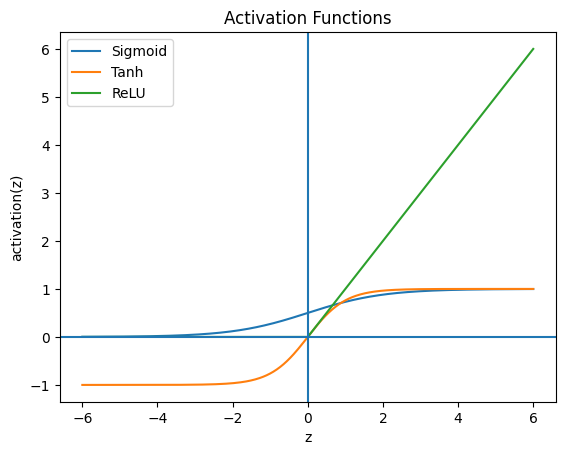

In [ ]:
import torch
import matplotlib.pyplot as plt

z = torch.linspace(-6, 6, 400)

sigmoid = 1 / (1 + torch.exp(-z))
tanh = torch.tanh(z)
relu = torch.relu(z)

plt.figure()
plt.plot(z.numpy(), sigmoid.numpy(), label="Sigmoid")
plt.plot(z.numpy(), tanh.numpy(), label="Tanh")
plt.plot(z.numpy(), relu.numpy(), label="ReLU")

plt.axhline(0)
plt.axvline(0)

plt.title("Activation Functions")
plt.xlabel("z")
plt.ylabel("activation(z)")
plt.legend()
plt.show()


### Concept Check

1. Why does stacking linear layers collapse into one layer?

2. Which activation functions saturate for large $|z|$?

3. What happens to gradients in the saturation region?

4. Why does ReLU avoid saturation for positive values?

5. Can a 3-layer network without activations represent $y = x^2$?


# SECTION 3 — Forward Propagation

We now write the complete forward pass for a 2-layer ANN.

---

## Network Structure

Let:

- Input dimension: $d$
- Hidden units: $h$
- Output units: $o$
- Batch size: $N$

Input:

$$
X \in \mathbb{R}^{N \times d}
$$

Parameters:

$$
W_1 \in \mathbb{R}^{h \times d}, \quad b_1 \in \mathbb{R}^{h}
$$

$$
W_2 \in \mathbb{R}^{o \times h}, \quad b_2 \in \mathbb{R}^{o}
$$

---

## Forward Pass Equations

### Hidden Layer

$$
Z^{(1)} = X W_1^T + b_1
$$

$$
A^{(1)} = \phi(Z^{(1)})
$$

### Output Layer

$$
Z^{(2)} = A^{(1)} W_2^T + b_2
$$

For regression:

$$
\hat{y} = Z^{(2)}
$$

---

## Tensor Flow

$$
(N, d) \rightarrow (N, h) \rightarrow (N, o)
$$

Always verify dimensions at every step.


In [ ]:
import torch

torch.manual_seed(0)

# Dimensions
N, d, h, o = 5, 2, 4, 1

# Batch input
X = torch.randn(N, d)

# Parameters
W1 = torch.randn(h, d)
b1 = torch.randn(h)

W2 = torch.randn(o, h)
b2 = torch.randn(o)

# Forward Pass
Z1 = X @ W1.T + b1
A1 = torch.relu(Z1)
Z2 = A1 @ W2.T + b2
yhat = Z2

print("X shape:", X.shape)
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)
print("Z2 shape:", Z2.shape)
print("yhat shape:", yhat.shape)


X shape: torch.Size([5, 2])
W1 shape: torch.Size([4, 2])
b1 shape: torch.Size([4])
Z1 shape: torch.Size([5, 4])
A1 shape: torch.Size([5, 4])
W2 shape: torch.Size([1, 4])
b2 shape: torch.Size([1])
Z2 shape: torch.Size([5, 1])
yhat shape: torch.Size([5, 1])


## What Does the Hidden Layer Do?

Each hidden neuron computes:

$$
z_j^{(1)} = w_j^T x + b_j
$$

After activation:

$$
a_j^{(1)} = \phi(z_j^{(1)})
$$

This means:

- Each neuron defines a hyperplane in input space
- Activation bends the linear space
- The hidden layer creates a new feature representation

So the hidden layer performs:

> Linear projection → Nonlinear transformation → Feature creation


## Implementing the Same Network Using nn.Module

PyTorch stores linear layers as:

$$
\text{weight shape} = (out\_features, in\_features)
$$

So:

- nn.Linear(d, h) stores weight of shape $(h, d)$
- Forward internally computes:

$$
X W^T + b
$$

We now implement the same network using nn.Module.


In [ ]:
import torch
import torch.nn as nn

class TwoLayerANN(nn.Module):
    def __init__(self, d_in, h, d_out):
        super().__init__()
        self.fc1 = nn.Linear(d_in, h)
        self.fc2 = nn.Linear(h, d_out)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = torch.relu(z1)
        z2 = self.fc2(a1)
        return z1, a1, z2


torch.manual_seed(0)

model = TwoLayerANN(d_in=2, h=4, d_out=1)

X = torch.randn(5, 2)

z1, a1, yhat = model(X)

print("X shape:", X.shape)
print("z1 shape:", z1.shape)
print("a1 shape:", a1.shape)
print("yhat shape:", yhat.shape)

print("\nParameter shapes:")
print("fc1 weight:", model.fc1.weight.shape)
print("fc1 bias:", model.fc1.bias.shape)
print("fc2 weight:", model.fc2.weight.shape)
print("fc2 bias:", model.fc2.bias.shape)


X shape: torch.Size([5, 2])
z1 shape: torch.Size([5, 4])
a1 shape: torch.Size([5, 4])
yhat shape: torch.Size([5, 1])

Parameter shapes:
fc1 weight: torch.Size([4, 2])
fc1 bias: torch.Size([4])
fc2 weight: torch.Size([1, 4])
fc2 bias: torch.Size([1])


## Why Return Intermediate Values?

We returned:

- $Z^{(1)}$
- $A^{(1)}$

Why?

Because:

1. They help us understand shape flow.
2. They are needed for backpropagation (Lecture 2).
3. Debugging neural networks requires inspecting internal activations.

Deep learning becomes transparent only when you inspect intermediate tensors.


### Concept Check

1. If input shape is $(N, d)$ and first layer is nn.Linear(d, h),
   what is the shape of its weight matrix?

2. What is the shape of $Z^{(1)}$?

3. What changes if we remove ReLU from the forward pass?

4. Why do we say hidden layer creates "features"?


# SECTION 4 — Nonlinear Function Approximation

We now train a small ANN to approximate:

$$
y = x^2
$$

This function is **nonlinear**.

A purely linear model:

$$
\hat{y} = wx + b
$$

cannot represent curvature because:

$$
\frac{d^2}{dx^2}(wx + b) = 0
$$

But:

$$
\frac{d^2}{dx^2}(x^2) = 2
$$

So we require a nonlinear model.

---

## Goal

Show that:

> A hidden layer + activation enables nonlinear function approximation.


x shape: torch.Size([200, 1])
y shape: torch.Size([200, 1])


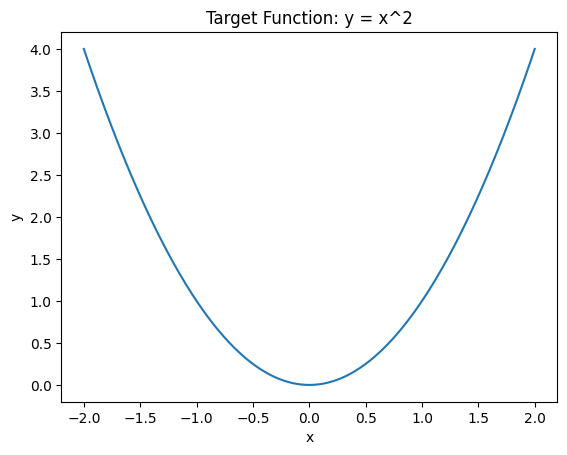

In [ ]:
torch.manual_seed(0)

# Generate data
N = 200
x = torch.linspace(-2, 2, N).unsqueeze(1)   # (N, 1)
y = x ** 2                                  # (N, 1)

print("x shape:", x.shape)
print("y shape:", y.shape)

# Plot true function
plt.figure()
plt.plot(x.squeeze().numpy(), y.squeeze().numpy())
plt.title("Target Function: y = x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## Network Architecture

We use a 2-layer ANN:

Hidden layer:

$$
Z^{(1)} = X W_1^T + b_1
$$

$$
A^{(1)} = \text{ReLU}(Z^{(1)})
$$

Output layer:

$$
\hat{y} = A^{(1)} W_2^T + b_2
$$

Tensor Flow:

$$
(N,1) \rightarrow (N,h) \rightarrow (N,1)
$$

The hidden layer creates nonlinear features.
The output layer linearly combines those features.


In [ ]:
import torch.nn as nn

class SmallANN(nn.Module):
    def __init__(self, hidden=20):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        z1 = self.fc1(x)        # (N, hidden)
        a1 = torch.relu(z1)     # (N, hidden)
        yhat = self.fc2(a1)     # (N, 1)
        return z1, a1, yhat


torch.manual_seed(0)
model = SmallANN(hidden=32)

# Inspect parameter shapes
print("fc1 weight:", model.fc1.weight.shape)
print("fc2 weight:", model.fc2.weight.shape)


fc1 weight: torch.Size([32, 1])
fc2 weight: torch.Size([1, 32])


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

loss_history = []

for epoch in range(301):

    z1, a1, yhat = model(x)

    loss = criterion(yhat, y)


    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_history.append(loss.item())

    if epoch in [0, 1, 2, 10, 100, 300]:
        print(f"Epoch {epoch:3d} | Loss = {loss.item():.6f}")
        print("  z1 shape:", z1.shape)
        print("  a1 shape:", a1.shape)
        print("  yhat shape:", yhat.shape)


Epoch   0 | Loss = 2.932542
  z1 shape: torch.Size([200, 32])
  a1 shape: torch.Size([200, 32])
  yhat shape: torch.Size([200, 1])
Epoch   1 | Loss = 1.128915
  z1 shape: torch.Size([200, 32])
  a1 shape: torch.Size([200, 32])
  yhat shape: torch.Size([200, 1])
Epoch   2 | Loss = 0.891120
  z1 shape: torch.Size([200, 32])
  a1 shape: torch.Size([200, 32])
  yhat shape: torch.Size([200, 1])
Epoch  10 | Loss = 0.466397
  z1 shape: torch.Size([200, 32])
  a1 shape: torch.Size([200, 32])
  yhat shape: torch.Size([200, 1])
Epoch 100 | Loss = 0.017005
  z1 shape: torch.Size([200, 32])
  a1 shape: torch.Size([200, 32])
  yhat shape: torch.Size([200, 1])
Epoch 300 | Loss = 0.008302
  z1 shape: torch.Size([200, 32])
  a1 shape: torch.Size([200, 32])
  yhat shape: torch.Size([200, 1])


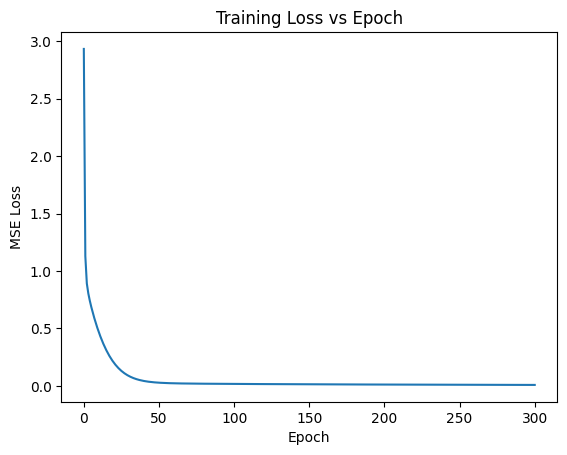

In [ ]:
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


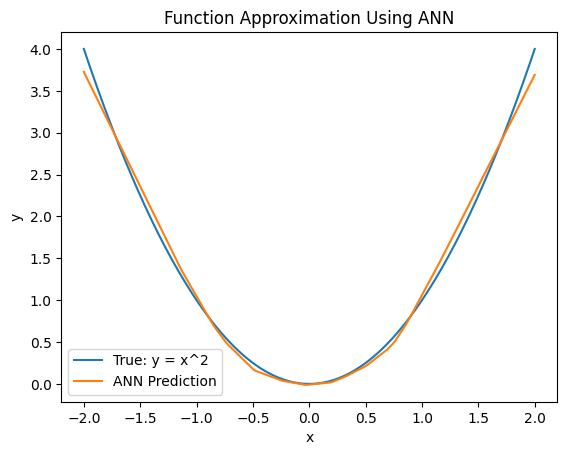

In [ ]:
with torch.no_grad():
    _, _, predictions = model(x)

plt.figure()
plt.plot(x.squeeze().numpy(), y.squeeze().numpy(), label="True: y = x^2")
plt.plot(x.squeeze().numpy(), predictions.squeeze().numpy(), label="ANN Prediction")
plt.legend()
plt.title("Function Approximation Using ANN")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## Why Does the Network Approximate a Curve?

ReLU creates piecewise linear functions:

$$
\text{ReLU}(z) = \max(0, z)
$$

Each hidden neuron introduces a "kink" (change in slope).

By combining many such neurons, the network builds:

> A piecewise linear approximation of a curved function.

The hidden layer transforms input into nonlinear features.
The output layer mixes those features to approximate curvature.

---

### Big Insight

Deep learning =

$$
\text{Linear Transformation} + \text{Nonlinear Activation}
$$

Repeated multiple times.


### Concept Check

1. Why can a linear model not fit $y = x^2$?

2. What is the shape of:
   - $Z^{(1)}$
   - $A^{(1)}$
   - $\hat{y}$ ?

3. Why does increasing the number of hidden units improve approximation ability?

4. What would happen if we removed ReLU from this network?


# Lecture 1 Summary

We have learned:

1. A layer is a matrix transformation:

$$
Z = XW^T + b
$$

2. Activation introduces nonlinearity:

$$
A = \phi(Z)
$$

3. Without activation, stacked layers collapse into one affine map.

4. With activation, networks can approximate nonlinear functions.

---

## Core Flow

Matrix Transformations  
→ Nonlinearity  
→ Feature Creation  
→ Function Approximation

This is the foundation of Artificial Neural Networks.


# SECTION 1 — Loss in Artificial Neural Networks

In supervised learning, the network produces predictions:

$$
\hat{y} = f(X; W, b)
$$

But we must measure:

> How far is the prediction from the true target $y$?

That measurement is called the **loss function**.

---

## Loss as a Function of Parameters

The loss depends on:

- Predictions $\hat{y}$
- Targets $y$
- Network parameters $W, b$

So mathematically:

$$
L = L(W, b)
$$

This means:

> Training a neural network = minimizing $L(W, b)$


## Mean Squared Error (MSE)

For regression problems, we commonly use:

$$
L = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2
$$

In vector form:

$$
L = \frac{1}{N} \| \hat{y} - y \|^2
$$

Where:

- $\hat{y} \in \mathbb{R}^{N \times 1}$
- $y \in \mathbb{R}^{N \times 1}$

---

## Interpretation

- Penalizes large errors more heavily
- Smooth and differentiable
- Suitable for regression tasks


In [ ]:
torch.manual_seed(0)

# Dummy predictions and targets
N = 5
y_true = torch.randn(N, 1)
y_pred = torch.randn(N, 1)

# Manual MSE
mse_manual = ((y_pred - y_true) ** 2).mean()

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("MSE:", mse_manual.item())


y_true shape: torch.Size([5, 1])
y_pred shape: torch.Size([5, 1])
MSE: 4.070003509521484


## Cross-Entropy Loss (Conceptual Overview)

Used for classification.

For binary classification:

$$
L = -\frac{1}{N} \sum_{i=1}^{N}
\left[
y_i \log(\hat{y}_i) +
(1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

Where:

- $\hat{y}_i$ is predicted probability
- $y_i \in \{0,1\}$

---

## Why Cross-Entropy?

- Measures difference between true distribution and predicted distribution
- Strongly penalizes confident wrong predictions
- Works naturally with sigmoid or softmax outputs


In [ ]:
import torch.nn as nn

# Simulated probabilities
y_true = torch.tensor([[1.0], [0.0], [1.0]])
y_pred = torch.tensor([[0.9], [0.2], [0.6]])

criterion = nn.BCELoss()
loss = criterion(y_pred, y_true)

print("Binary Cross-Entropy Loss:", loss.item())


Binary Cross-Entropy Loss: 0.27977654337882996


## Loss as a Function of Network Parameters

Recall:

$$
\hat{y} = f(X; W_1, b_1, W_2, b_2)
$$

So loss becomes:

$$
L = L(W_1, b_1, W_2, b_2)
$$

This is a function defined over a high-dimensional space.

For example:

If:
- $W_1$ has 16 × 1 parameters
- $W_2$ has 1 × 16 parameters

Then total parameters > 30.

Loss is a surface in this parameter space.

Training = moving downhill on this surface.


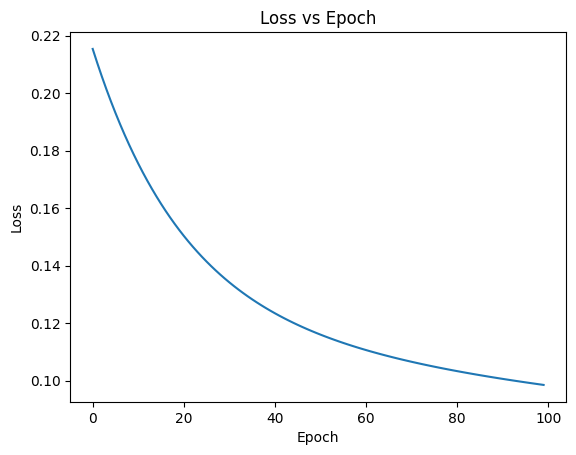

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Simple regression data
x = torch.linspace(-1, 1, 100).unsqueeze(1)
y = x ** 2

model = nn.Sequential(
    nn.Linear(1, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(100):
    y_pred = model(x)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

plt.figure()
plt.plot(loss_history)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


### Concept Check

1. Why do we need a loss function?

2. What does MSE penalize more: small errors or large errors?

3. Why is cross-entropy preferred for classification?

4. Why do we say loss is a function of all network parameters?


# SECTION 2 — Backpropagation

We defined loss:

$$
L = L(W_1, b_1, W_2, b_2)
$$

Training means:

$$
\min_{W_1, b_1, W_2, b_2} L
$$

But how do we minimize it?

---

## Gradient Descent Idea

We update parameters in the direction of **negative gradient**:

$$
W \leftarrow W - \eta \frac{\partial L}{\partial W}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

Where:

- $\eta$ = learning rate
- $\frac{\partial L}{\partial W}$ tells us how loss changes when $W$ changes

---

## Interpretation

Gradient = direction of steepest increase.

So:

> Move opposite to gradient → loss decreases.


## Chain Rule (Scalar Version)

Suppose:

$$
y = f(u)
$$

and

$$
u = g(x)
$$

Then:

$$
\frac{dy}{dx} =
\frac{dy}{du}
\cdot
\frac{du}{dx}
$$

---

## Neural Network Case

Loss depends on output.

Output depends on hidden layer.

Hidden layer depends on parameters.

So gradients must flow:

Loss → Output → Hidden → Parameters

This is called **Backpropagation**.


## Forward Pass Recap

Hidden layer:

$$
Z^{(1)} = X W_1^T + b_1
$$

$$
A^{(1)} = \phi(Z^{(1)})
$$

Output layer:

$$
Z^{(2)} = A^{(1)} W_2^T + b_2
$$

$$
\hat{y} = Z^{(2)}
$$

Loss (MSE):

$$
L = \frac{1}{N} \| \hat{y} - y \|^2
$$

---

## Step 1 — Gradient at Output

For MSE:

$$
\frac{\partial L}{\partial \hat{y}} =
\frac{2}{N}(\hat{y} - y)
$$

Shape:

$$
(N, o)
$$


## Step 2 — Gradients for $W_2$ and $b_2$

Recall:

$$
Z^{(2)} = A^{(1)} W_2^T + b_2
$$

Using chain rule:

$$
\frac{\partial L}{\partial W_2}
=
\left( \frac{\partial L}{\partial Z^{(2)}} \right)^T
A^{(1)}
$$

Shape reasoning:

- $\frac{\partial L}{\partial Z^{(2)}}$: $(N, o)$
- $A^{(1)}$: $(N, h)$
- Result: $(o, h)$

Matches shape of $W_2$.

---

Bias gradient:

$$
\frac{\partial L}{\partial b_2}
=
\sum_{i=1}^{N}
\frac{\partial L}{\partial Z^{(2)}_i}
$$

Shape: $(o)$


## Step 3 — Gradient Flows Back to Hidden Layer

Loss affects hidden layer through output layer.

$$
\frac{\partial L}{\partial A^{(1)}}
=
\frac{\partial L}{\partial Z^{(2)}}
W_2
$$

Shape:

- $(N, o)$ × $(o, h)$
- Result: $(N, h)$

Now apply activation derivative:

$$
\frac{\partial L}{\partial Z^{(1)}}
=
\frac{\partial L}{\partial A^{(1)}}
\odot
\phi'(Z^{(1)})
$$

Where $\odot$ is elementwise multiplication.

---

## Step 4 — Gradients for $W_1$

$$
\frac{\partial L}{\partial W_1}
=
\left( \frac{\partial L}{\partial Z^{(1)}} \right)^T
X
$$

Shape:

- $(h, N)$ × $(N, d)$
- Result: $(h, d)$

Matches $W_1$.


In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(0)

# Simple 2-layer model
model = nn.Sequential(
    nn.Linear(1, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

# Data
x = torch.linspace(-1, 1, 20).unsqueeze(1)
y = x ** 2

criterion = nn.MSELoss()

# Forward
y_pred = model(x)
loss = criterion(y_pred, y)

# Backward
loss.backward()

# Inspect gradients
for name, param in model.named_parameters():
    print(name)
    print("  shape:", param.shape)
    print("  grad shape:", param.grad.shape)
    print("  grad mean magnitude:", param.grad.abs().mean().item())


0.weight
  shape: torch.Size([4, 1])
  grad shape: torch.Size([4, 1])
  grad mean magnitude: 0.041752804070711136
0.bias
  shape: torch.Size([4])
  grad shape: torch.Size([4])
  grad mean magnitude: 0.12145772576332092
2.weight
  shape: torch.Size([1, 4])
  grad shape: torch.Size([1, 4])
  grad mean magnitude: 0.6503108143806458
2.bias
  shape: torch.Size([1])
  grad shape: torch.Size([1])
  grad mean magnitude: 1.8292731046676636


## Understanding Gradient Magnitude

Large gradients:
- Big parameter updates
- Risk of instability

Small gradients:
- Very slow learning
- Possible vanishing gradient

Gradient magnitude tells us:

> How strongly each layer is responsible for correcting the error.


### Concept Check

1. Why must gradients flow backward from output to hidden layer?

2. Why does $\frac{\partial L}{\partial W_2}$ involve $A^{(1)}$?

3. Why does gradient for $W_1$ involve input $X$?

4. What would happen if activation derivative is near zero?


# SECTION 3 — Training Dynamics

We now understand:

$$
\frac{\partial L}{\partial W}
$$

But training depends on how we use it.

---

## Gradient Descent Update Rule

$$
W \leftarrow W - \eta \frac{\partial L}{\partial W}
$$

Where:

- $\eta$ = learning rate
- $\frac{\partial L}{\partial W}$ = gradient

---

## Interpretation

Gradient = direction  
Learning rate = step size  

Training behavior depends critically on $\eta$.


## Role of Learning Rate

Small $\eta$:

- Very small steps
- Slow convergence
- Stable but inefficient

Large $\eta$:

- Large parameter jumps
- May overshoot minimum
- Risk of divergence

---

## Key Insight

Optimization is not just about gradients.

It is about:

Gradient × Learning Rate


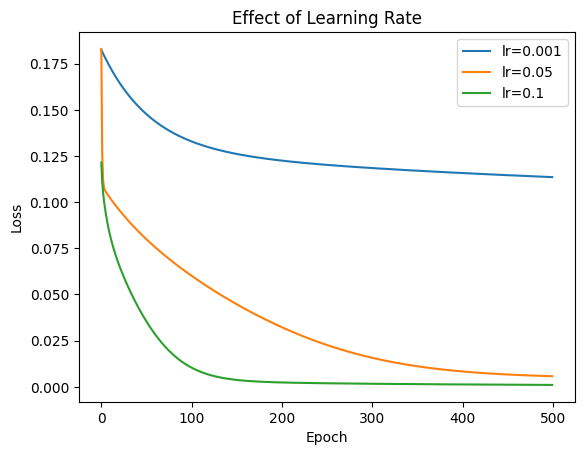

In [ ]:
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Data
x = torch.linspace(-1, 1, 100).unsqueeze(1)
y = x ** 2

def train_model(lr):
    model = nn.Sequential(
        nn.Linear(1, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    losses = []

    for epoch in range(500):
        y_pred = model(x)
        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

loss_small = train_model(0.001)
loss_medium = train_model(0.05)
loss_large = train_model(0.1)

plt.figure()
plt.plot(loss_small, label="lr=0.001")
plt.plot(loss_medium, label="lr=0.05")
plt.plot(loss_large, label="lr=0.1")
plt.legend()
plt.title("Effect of Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


## Convergence Behavior

Ideal training:

- Loss decreases smoothly
- Gradients gradually shrink
- Model approaches minimum

Possible failure modes:

1. Divergence — loss explodes
2. Oscillation — loss fluctuates
3. Plateau — loss stops decreasing

---

## Why Do These Happen?

- Learning rate too large
- Poor initialization
- Vanishing gradients
- Ill-conditioned loss surface

## Tracking Gradient Magnitude

During training, we can inspect:

$$
\|\nabla L\|
$$

Large gradient norms → unstable updates  
Tiny gradient norms → slow learning  

Monitoring gradients helps diagnose training issues.

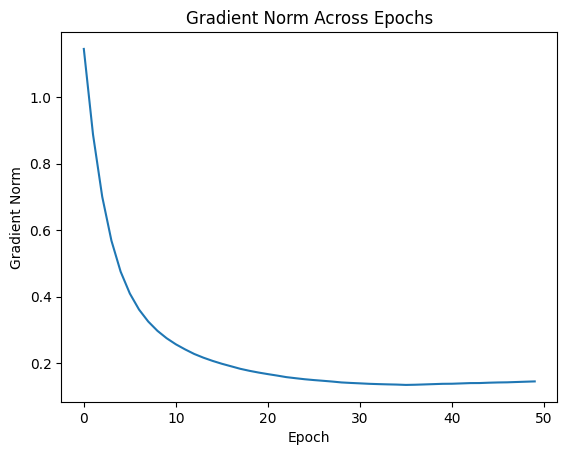

In [ ]:
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(1, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
criterion = nn.MSELoss()

gradient_norms = []

for epoch in range(50):
    y_pred = model(x)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()

    total_norm = 0
    for param in model.parameters():
        total_norm += param.grad.norm().item()

    gradient_norms.append(total_norm)

    optimizer.step()

plt.figure()
plt.plot(gradient_norms)
plt.title("Gradient Norm Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.show()

### Concept Check

1. Why can a large learning rate cause divergence?

2. What happens if learning rate is extremely small?

3. Why is gradient norm useful to monitor?

4. If gradient norm becomes very small early in training, what might be happening?

# SECTION 4 — Underfitting vs Overfitting

Training minimizes loss on the training data.

But the true goal is:

> Perform well on unseen data.

This ability is called **Generalization**.

---

## Two Types of Error

1. Training Error
2. Validation (Test) Error

If both are low → good model.

If training is low but validation is high → overfitting.

If both are high → underfitting.

## Underfitting

Underfitting occurs when:

- Model is too simple
- Cannot capture underlying pattern
- High training loss
- High validation loss

Example:

Trying to fit $y = x^2$ using a linear model:

$$
\hat{y} = wx + b
$$

This model cannot represent curvature.

## Overfitting

Overfitting occurs when:

- Model is too complex
- Fits noise in training data
- Very low training loss
- High validation loss

Model memorizes instead of learning pattern.

---

## Intuition

Underfitting → High Bias  
Overfitting → High Variance

## Bias–Variance Tradeoff

Bias:
- Error from incorrect assumptions
- Model too simple

Variance:
- Error from sensitivity to data fluctuations
- Model too complex

Goal:

Find balance between bias and variance.

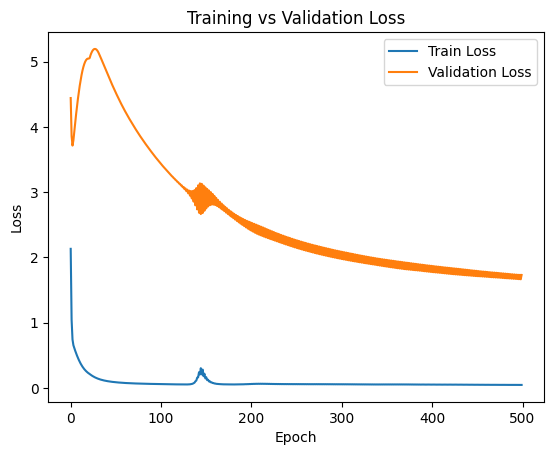

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Create noisy dataset
x = torch.linspace(-2, 2, 1000).unsqueeze(1)
y_true = x ** 2
noise = 0.2 * torch.randn_like(y_true)
y_noisy = y_true + noise

# Split into train/validation
train_x = x[:750]
train_y = y_noisy[:750]

val_x = x[750:]
val_y = y_noisy[750:]

# Model with large capacity
model = nn.Sequential(
    nn.Linear(1, 8),
    nn.ReLU(),
    nn.Linear(8,16),
    nn.ReLU(),
    nn.Linear(16,1),
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.09)
criterion = nn.MSELoss()

train_losses = []
val_losses = []

for epoch in range(500):

    # Training
    y_pred = model(train_x)
    train_loss = criterion(y_pred, train_y)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_pred = model(val_x)
        val_loss = criterion(val_pred, val_y)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Model Capacity

Capacity = ability of model to fit complex functions.

Increasing:

- Number of layers
- Number of neurons

→ increases capacity

Too low capacity → underfitting  
Too high capacity → overfitting  

---

## Key Insight

Good training loss does NOT guarantee good generalization.

### Concept Check

1. What is the difference between training error and validation error?

2. Why does overfitting produce low training loss but high validation loss?

3. How does increasing model capacity affect bias and variance?

4. Can a very small network overfit? Why or why not?

# SECTION 5 — Real-World ANN Use Cases

Artificial Neural Networks are used whenever:

- The relationship between inputs and outputs is complex
- Data is high-dimensional
- Linear models are insufficient

Recall:

Matrix Transformations  
→ Nonlinearity  
→ Function Approximation  

This is exactly what many real-world problems require.

## 1. Regression Problems

Goal:

$$
\text{Predict continuous values}
$$

Examples:

- House price prediction
- Demand forecasting
- Energy consumption estimation
- Healthcare risk scoring

In regression:

- Output layer often uses identity activation
- Loss = Mean Squared Error (MSE)

## 2. Classification Problems

Goal:

$$
\text{Predict discrete categories}
$$

Binary classification:

- Fraud vs Non-fraud
- Disease vs Healthy

Multi-class classification:

- Digit recognition (0–9)
- Product category classification

In classification:

- Output layer often uses Sigmoid or Softmax
- Loss = Cross-Entropy

## 3. Fraud Detection

Input features may include:

- Transaction amount
- Time of transaction
- Location
- User behavior history

ANN learns nonlinear relationships between:

$$
\text{User behavior patterns} \rightarrow \text{Fraud probability}
$$

Why ANN?

Fraud patterns are rarely linearly separable.

## 4. Healthcare Prediction

Examples:

- Disease risk prediction
- Survival probability
- Hospital readmission risk

Inputs may include:

- Lab measurements
- Demographic features
- Medical history

ANN models complex interactions between biological variables.

## 5. Image and Speech Applications

Although CNNs and RNNs are specialized forms,
their foundation is still:

$$
Z = XW^T + b
$$

plus nonlinear activation.

Examples:

- Image recognition
- Speech recognition
- Face detection
- Autonomous vehicles

Core idea remains:

Matrix multiplications + Nonlinearity + Loss minimization.

### Concept Check

1. Why are neural networks powerful for fraud detection?

2. Why is MSE not suitable for classification?

3. What makes ANN suitable for healthcare data?

4. What is common between regression and classification networks?

# SECTION 6 — Conceptual Closure

We now connect everything learned in Lecture 1 and Lecture 2.

---

## The Complete ANN Pipeline

1. Matrix Transformation

$$
Z = XW^T + b
$$

2. Nonlinearity

$$
A = \phi(Z)
$$

3. Loss Computation

$$
L = L(\hat{y}, y)
$$

4. Backpropagation

$$
\nabla L
$$

5. Parameter Update

$$
W \leftarrow W - \eta \nabla L
$$

6. Generalization Evaluation
   - Training loss
   - Validation loss

## ANN as Nested Functions

A neural network is a composition of functions:

$$
\hat{y} = f_2(f_1(X))
$$

Loss is:

$$
L = L(f_2(f_1(X)), y)
$$

Backpropagation applies chain rule:

$$
\frac{\partial L}{\partial W_1}
=
\frac{\partial L}{\partial f_2}
\cdot
\frac{\partial f_2}{\partial f_1}
\cdot
\frac{\partial f_1}{\partial W_1}
$$

Deep learning is structured chain rule over matrix operations.

## How Layers Share Responsibility

Output layer:
- Directly compares prediction with target

Hidden layers:
- Indirectly responsible
- Adjust internal feature representations

Each layer answers:

> How should I change so final prediction improves?

This is encoded in gradient magnitude.

## Expressivity vs Generalization

Increasing capacity:

- More neurons
- More layers

→ increases function approximation power.

But also increases risk of:

- Overfitting
- High variance

Training success requires balance:

Capacity  
+ Optimization  
+ Proper learning rate  
+ Sufficient data

## The Core Equation of Deep Learning

Everything reduces to:

$$
\textbf{Linear Algebra} + \textbf{Calculus}
$$

Linear Algebra:
- Matrix multiplication
- Vector spaces
- Feature transformation

Calculus:
- Chain rule
- Gradients
- Optimization

Together they enable:

Nonlinear function learning.

# Final Mental Model

Neural Network Learning =

Matrix Transformations  
→ Nonlinearity  
→ Loss Computation  
→ Gradient Computation  
→ Parameter Update  
→ Generalization Check  

Repeat until convergence.

### Final Concept Check

1. Why is nonlinearity essential in deep networks?

2. Why is loss considered a function of all parameters?

3. What does gradient magnitude tell us?

4. Why can a model with low training loss still perform poorly?

5. What is the mathematical tool that enables backpropagation?